# CSC2541

End-to-end pipeline: download ChEMBL molecules → featurize → generate analogs via PrexSyn → score results.

Each section can be run independently if intermediate files already exist.

In [1]:
import pathlib

# ── paths (edit here to change defaults) ──────────────────────────────────────
DATA_DIR         = pathlib.Path("data")
CHEMBL_FULL_CSV  = DATA_DIR / "chembl_full.csv"       # all filtered molecules (~1.8M)
CHEMBL_CSV       = DATA_DIR / "chembl_sampled.csv"    # sampled subset for this run
CHEMBL_CACHE     = DATA_DIR / "chembl_35_chemreps.txt.gz"
FEATURES_NPZ     = DATA_DIR / "chembl_features.npz"
SAMPLES_JSON     = DATA_DIR / "prexsyn_sampled.json"
SCORES_CSV       = DATA_DIR / "chembl_scores.csv"

# ── pipeline settings ─────────────────────────────────────────────────────────
NUM_MOLECULES = 100       # molecules to sample from ChEMBL for this benchmark
SEED          = 42
NUM_SAMPLES   = 64         # analog samples per molecule from PrexSyn
API_URL       = "http://localhost:8011/sample"
LIMIT         = None       # set to e.g. 10 for a quick test run

## 1. Download ChEMBL

Downloads the full ChEMBL release, filters for valid drug-like organic molecules, and saves the complete set.  
This file is large (~1.8M molecules) but only needs to be downloaded once — reuse it across experiments by changing `SEED` or `NUM_MOLECULES` in the next cell.  
Skipped automatically if the output file already exists.

In [2]:
from download_chembl import download

if CHEMBL_FULL_CSV.exists():
    print(f"Already exists, skipping download: {CHEMBL_FULL_CSV}")
else:
    download(output=CHEMBL_FULL_CSV, cache=CHEMBL_CACHE)

Already exists, skipping download: data\chembl_full.csv


## 2. Sample from ChEMBL

Randomly samples `NUM_MOLECULES` from the full filtered set.  
Change `SEED` or `NUM_MOLECULES` above and re-run this cell to get a different subset — no need to re-download.

In [3]:
from download_chembl import sample as sample_chembl

sample_chembl(input=CHEMBL_FULL_CSV, output=CHEMBL_CSV, num_molecules=NUM_MOLECULES, seed=SEED)

Loaded 1,794,749 molecules from data\chembl_full.csv
Sampled 100 molecules → data\chembl_sampled.csv


WindowsPath('data/chembl_sampled.csv')

## 3. Featurize

Computes ECFP4, FCFP4, RDKit descriptors, and BRICS fragment fingerprints for each molecule.  
Output is a `.npz` file with arrays shaped `(N, ...)`.  
Skipped if the output file already exists.

In [4]:
from featurize_chembl import featurize

if FEATURES_NPZ.exists():
    print(f"Already exists, skipping featurization: {FEATURES_NPZ}")
else:
    featurize(input=CHEMBL_CSV, output=FEATURES_NPZ)

Already exists, skipping featurization: data\chembl_features.npz


In [5]:
# Inspect the feature arrays
import numpy as np

data = np.load(FEATURES_NPZ, allow_pickle=True)
for key in ["smiles", "ecfp4", "fcfp4", "rdkit_desc_values", "brics_fps", "brics_exists"]:
    arr = data[key]
    print(f"  {key:25s}: shape={arr.shape}  dtype={arr.dtype}")

  smiles                   : shape=(100,)  dtype=object
  ecfp4                    : shape=(100, 2048)  dtype=float32
  fcfp4                    : shape=(100, 2048)  dtype=float32
  rdkit_desc_values        : shape=(100, 43)  dtype=float32
  brics_fps                : shape=(100, 8, 2048)  dtype=float32
  brics_exists             : shape=(100, 8)  dtype=bool


## 4. Generate Analogs

Sends each molecule's features to the PrexSyn `/sample` API (QuerySampler with product-of-experts over all 5 properties).  
Make sure the Docker container is running: `docker start prexsyn`  
Set `LIMIT` above to a small number (e.g. 10) for a quick test.

In [6]:
import urllib.request

# Check API health before running
try:
    resp = urllib.request.urlopen("http://localhost:8011/health", timeout=5)
    print("API status:", resp.read().decode())
except Exception as e:
    print(f"API not reachable: {e}\nStart with: docker start prexsyn")

API status: {"status":"ok"}


In [7]:
from sampler import run_batch

run_batch(
    npz=FEATURES_NPZ,
    output=SAMPLES_JSON,
    url=API_URL,
    num_samples=NUM_SAMPLES,
    limit=LIMIT,
)

Processing 100 molecules → http://localhost:8011/sample


100%|██████████| 100/100 [01:19<00:00,  1.25it/s]

Done: 100 succeeded, 0 failed
Total generated molecules: 4221
Saved to data\prexsyn_sampled.json


WindowsPath('data/prexsyn_sampled.json')

## 5. Score Generated Molecules

Scores every generated SMILES against its source molecule:
- **Tanimoto** (ECFP4) — structural similarity
- **Desirability** — QED × Lipinski penalty × MW penalty × rotatable bonds penalty
- **Hit** — similar (≥ 0.3) AND drug-like (≥ 0.2) AND novel (< 1.0 Tanimoto)

In [8]:
import json
from scoring import score_results, summarize

results = json.loads(SAMPLES_JSON.read_text())
print(f"Loaded {len(results)} source molecules")
print(f"Total generated: {sum(len(r.get('generated_smiles', [])) for r in results)}")

df = score_results(results, similarity_threshold=0.3, desirability_threshold=0.2, novelty_threshold=1.0)
df.to_csv(SCORES_CSV, index=False)
print(f"Saved {len(df)} scored rows to {SCORES_CSV}")

Loaded 100 source molecules
Total generated: 4221
Saved 3707 scored rows to data\chembl_scores.csv


## 6. Results

In [9]:
# Overall statistics
df[["tanimoto", "qed", "desirability", "is_hit", "is_similar", "is_drug_like", "is_novel"]].describe().round(3)

,tanimoto,qed,desirability
count,3707.000,3707.000,3707.000
mean,0.323,0.424,0.251
std,0.139,0.217,0.250
min,0.038,0.007,0.000
25%,0.220,0.244,0.029
50%,0.301,0.412,0.159
75%,0.395,0.588,0.448
max,1.000,0.933,0.892


In [10]:
# Hit rate summary per source molecule (top 10)
summary = summarize(df)
summary.head(10)

,source_smiles,n_generated,n_hits,hit_rate,mean_tanimoto,max_tanimoto,mean_qed,mean_desirability,n_unique_scaffolds
74,Cl.N#CC(c1cccc(F)c1)N1CCOCC1,1,1,1.000000,0.971400,0.9714,0.761100,0.744600,1
50,COc1cc2oc(=O)ccc2c(OC)c1O,5,5,1.000000,0.441520,0.5349,0.545900,0.523900,3
40,COC(=O)C1=C(C)NC(=O)NC1c1cc(OC)c(O)c(OC)c1,4,4,1.000000,0.446450,0.5556,0.709325,0.617775,4
37,CN1CCC(C#N)(c2ccc3ccccc3c2)CC1,1,1,1.000000,0.735300,0.7353,0.680600,0.671600,1
94,O=C1N(c2ccccc2)C(=O)C(c2ccccc2)(c2ccccc2)N1Cn1...,3,3,1.000000,0.402533,0.5091,0.514367,0.411667,3
79,N#C[C@H](Cc1ccccc1)NC(=O)[C@@H](N)Cc1cccs1,4,4,1.000000,0.840475,0.9091,0.795550,0.656275,2
15,CC(c1cccc(C(=N)N)n1)C1OCCO1,11,10,0.909091,0.373600,0.4722,0.447373,0.434809,6
92,O=C1CC[C@@H]2[C@@H](CCN2C(=O)c2ccsc2)N1Cc1ccncc1,58,49,0.844828,0.410022,0.6607,0.744728,0.662936,57
21,CCC1CCCCN1C(=O)Cn1c(C(=O)OC)cc2ccsc21,17,14,0.823529,0.514312,0.6129,0.677106,0.495576,13
73,Cc1cn(-c2cc3c(c(C(C)(C)C)c2)C(=O)NCC3)c2c1C(=O...,15,12,0.800000,0.356053,0.4762,0.709447,0.566427,10


In [11]:
total_hits = int(df["is_hit"].sum())
print(f"Total hits : {total_hits} / {len(df)} ({100 * total_hits / len(df):.1f}%)")
print(f"Hit rate   : {df['is_hit'].mean():.3f}")
print(f"Mean Tanimoto : {df['tanimoto'].mean():.3f}")
print(f"Mean QED      : {df['qed'].mean():.3f}")
print(f"Unique scaffolds: {df['scaffold'].nunique()}")

Total hits : 831 / 3707 (22.4%)
Hit rate   : 0.224
Mean Tanimoto : 0.323
Mean QED      : 0.424
Unique scaffolds: 2222


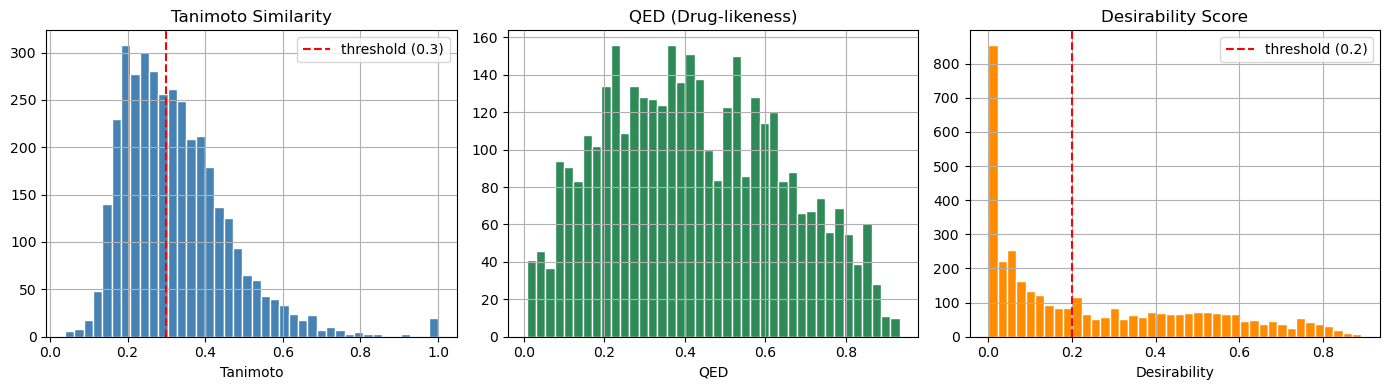

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["tanimoto"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(0.3, color="red", linestyle="--", label="threshold (0.3)")
axes[0].set_title("Tanimoto Similarity")
axes[0].set_xlabel("Tanimoto")
axes[0].legend()

df["qed"].hist(bins=40, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("QED (Drug-likeness)")
axes[1].set_xlabel("QED")

df["desirability"].hist(bins=40, ax=axes[2], color="darkorange", edgecolor="white")
axes[2].axvline(0.2, color="red", linestyle="--", label="threshold (0.2)")
axes[2].set_title("Desirability Score")
axes[2].set_xlabel("Desirability")
axes[2].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "score_distributions.png", dpi=150)
plt.show()